Task 1: Data Understanding and Visualization

1. Load and visualize images from a dataset stored in directories, where each subdirec-
tory represents a class.

Get the list of class directories from the train folder.

In [1]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Path to the train folder
train_dir = "/content/drive/MyDrive/AI-Worksheets/Worksheet-5/train"

# Step 1: Get class directories
classes = [cls for cls in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, cls))]

print("Classes found:", classes)

Classes found: ['pupunha', 'guarana', 'acai', 'cupuacu', 'graviola', 'tucuma']


Select one image randomly from each class.

In [3]:
images = []
labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)
    images.append(img)
    labels.append(cls)

Display the images in a grid format with two rows using matplotlib.

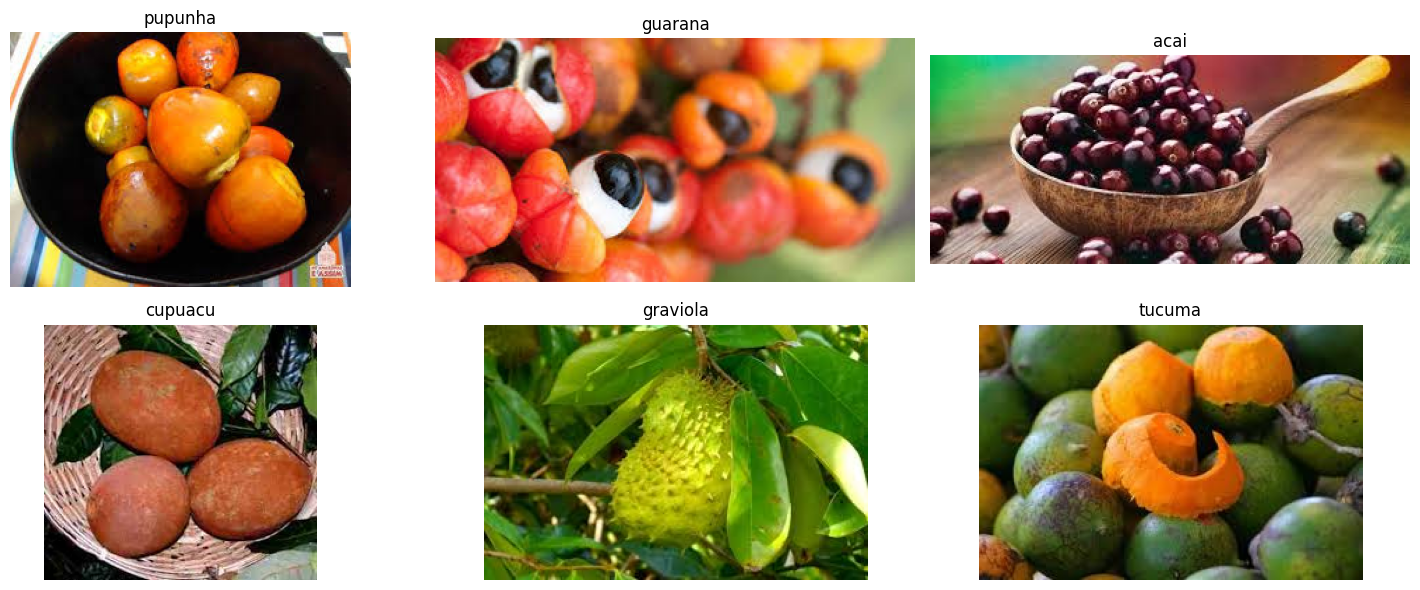

In [4]:
num_images = len(images)
cols = (num_images + 1) // 2  # distribute into 2 rows

plt.figure(figsize=(15, 6))

for i in range(num_images):
    plt.subplot(2, cols, i + 1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

2. Check for Corrupted Image: Write a script that verifies whether the image in the train
directory are valid. If any corrupted images are found, the script must remove the image from
the directory and print the message which image have been removed, if none found print ”No
Corrupted Images Found.”


In [5]:
import os
from PIL import Image

train_dir = "/content/drive/MyDrive/AI-Worksheets/Worksheet-5/train"

corrupted_images = []

# Iterate through each class folder
for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()  # check if image is valid
            except (IOError, SyntaxError):
                corrupted_images.append(img_path)
                os.remove(img_path)
                print(f"Removed corrupted image: {img_path}")

# Final output
if len(corrupted_images) == 0:
    print("No corrupted images found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No corrupted images found.


Task 2: Loading and Preprocessing Image Data in keras

In [6]:
import tensorflow as tf

# Path to dataset
train_dir = "/content/drive/MyDrive/AI-Worksheets/Worksheet-5/train"

# Parameters
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

Normalization layer

In [7]:
rescale = tf.keras.layers.Rescaling(1./255)

Training dataset

In [8]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)


Found 90 files belonging to 6 classes.
Using 72 files for training.


Apply Normalization

In [9]:
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

Validate dataset

In [10]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

Found 90 files belonging to 6 classes.
Using 18 files for validation.


Apply normalization

In [11]:
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Task 3: Implement a CNN

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Number of classes
num_classes = 6

model = models.Sequential()

Convolutional Layer 1

In [14]:
model.add(layers.Conv2D(32, (3,3), strides=1, padding='same', input_shape=(128,128,3)))

Activation Layer

In [15]:
model.add(layers.Activation('relu'))

Pooling Layer 1

In [16]:
model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))

Convolutional Layer 2

In [17]:
model.add(layers.Conv2D(32, (3,3), strides=1, padding='same'))

Activation Layer

In [18]:
model.add(layers.Activation('relu'))

Pooling Layer 2

In [19]:
model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))

Fully Connected Network Architecture:

Flatten Layer

In [20]:
model.add(layers.Flatten())

# Fully Connected Layers
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(128, activation='relu'))

Output Layer

In [21]:
# Output Layer
model.add(layers.Dense(num_classes, activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,125,702 (8.11 MB)

 Trainable params: 2,125,702 (8.11 MB)

 Non-trainable params: 0 (0.00 B)

Task 4: Compile the Model

In [23]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train the Model

In [24]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Callbacks
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 933ms/step - accuracy: 0.1655 - loss: 1.9019
Epoch 1: val_loss improved from None to 1.67295, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.1528 - loss: 1.9402 - val_accuracy: 0.0000e+00 - val_loss: 1.6730
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 955ms/step - accuracy: 0.1910 - loss: 1.7902
Epoch 2: val_loss did not improve from 1.67295
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.1667 - loss: 1.7931 - val_accuracy: 0.0000e+00 - val_loss: 1.7119
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2390 - loss: 1.7063
Epoch 3: val_loss did not improve from 1.67295
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.2639 - loss: 1.6836 - val_accuracy: 0.0000e+00 - val_loss: 1.8908
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 931ms/step - accuracy: 0.2494 - loss: 1.6056
Epoch 4: val_loss did not improve from 1.67295
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - ac

Task 5: Evaluate the Model

In [25]:
test_dir = "/content/drive/MyDrive/AI-Worksheets/Worksheet-5/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(128, 128),
    batch_size=16,
    shuffle=False
)

# Apply normalization (same as training)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 30 files belonging to 6 classes.


In [26]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.8333 - loss: 0.4732
Test Loss: 0.47315514087677
Test Accuracy: 0.8333333134651184


Task 6: Save and Load the Model

Save the Model

In [27]:
model.save("cnn_model.h5")

Load the Model

In [28]:
from tensorflow.keras.models import load_model

loaded_model = load_model("cnn_model.h5")

Re-evaluate on Test Data

In [29]:
test_loss, test_accuracy = loaded_model.evaluate(test_ds)

print("Loaded Model Test Loss:", test_loss)
print("Loaded Model Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step - accuracy: 0.8333 - loss: 0.4732
Loaded Model Test Loss: 0.47315514087677
Loaded Model Test Accuracy: 0.8333333134651184


Task 7: Predictions and Classification Report

Step 1: Make Predictions

In [30]:
import numpy as np

# Get predictions (probabilities)
predictions = model.predict(test_ds)

# Convert probabilities → class labels
predicted_labels = np.argmax(predictions, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step


Step 2: Get True Labels

In [31]:
true_labels = []

for images, labels in test_ds:
    true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)

Step 3: Classification Report

In [33]:
# Load test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(128, 128),
    batch_size=16,
    shuffle=False
)

# Save class names BEFORE mapping
class_names = test_ds.class_names

# Apply normalization
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 30 files belonging to 6 classes.


In [35]:
from sklearn.metrics import classification_report

report = classification_report(true_labels, predicted_labels, target_names=class_names)

print(report)

              precision    recall  f1-score   support

        acai       1.00      1.00      1.00         5
     cupuacu       0.83      1.00      0.91         5
    graviola       1.00      1.00      1.00         5
     guarana       1.00      0.40      0.57         5
     pupunha       0.80      0.80      0.80         5
      tucuma       0.57      0.80      0.67         5

    accuracy                           0.83        30
   macro avg       0.87      0.83      0.82        30
weighted avg       0.87      0.83      0.82        30

